In [ ]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import os
import re
import math
import random
import unicodedata
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torch.nn.utils.rnn import (
    pad_sequence,
    pack_padded_sequence,
    pad_packed_sequence
)

# Metrics
from nltk.translate.bleu_score import sentence_bleu

# Train/Test Split
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

In [ ]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
BATCH_SIZE = 128
EMBED_SIZE = 256
HIDDEN_SIZE = 256
NUM_LAYERS = 1
DROPOUT = 0.3
LEARNING_RATE = 0.001
NUM_EPOCHS = 5
MAX_LENGTH = 30
TEACHER_FORCING_RATIO = 0.5

In [ ]:
PAD_TOKEN = 0
SOS_TOKEN = 1
EOS_TOKEN = 2
UNK_TOKEN = 3

In [ ]:
df = pd.read_csv("/content/opus_en_uz_clean_sorted.csv", encoding_errors="ignore")

print(df.shape)

df.head()

(135626, 2)


,en,uz
0,ARS,ARS
1,UID,UID
2,FTP,FTP
3,Day,Kun
4,DOP,DOP


In [ ]:
df = df.dropna()

df = df.drop_duplicates()

df = df.reset_index(drop=True)

print(df.shape)

(135458, 2)


In [ ]:
def normalize_string(text):

    text = str(text).lower().strip()

    # unicode normalization
    text = unicodedata.normalize("NFKC", text)

    # replace multiple spaces
    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [ ]:
df["en"] = df["en"].apply(normalize_string)
df["uz"] = df["uz"].apply(normalize_string)

In [ ]:
df = df[
    (df["en"].str.len() > 0) &
    (df["uz"].str.len() > 0)
]

df = df.reset_index(drop=True)

print(df.shape)

(135458, 2)


In [ ]:
df["en_len"] = df["en"].apply(
    lambda x: len(x.split())
)

df["uz_len"] = df["uz"].apply(
    lambda x: len(x.split())
)

In [ ]:
MIN_LEN = 2
MAX_LEN = 30

df = df[
    (df["en_len"] >= MIN_LEN) &
    (df["en_len"] <= MAX_LEN) &
    (df["uz_len"] >= MIN_LEN) &
    (df["uz_len"] <= MAX_LEN)
]

df = df.reset_index(drop=True)

print(df.shape)

(114480, 4)


In [ ]:
for i in range(5):

    print("EN:", df["en"][i+2000])
    print("UZ:", df["uz"][i+2000])

    print("-" * 50)

EN: stay offline
UZ: oflayn qolish
--------------------------------------------------
EN: disc burning
UZ: diskka yozish
--------------------------------------------------
EN: plugin error
UZ: plagin xatosi
--------------------------------------------------
EN: & daily
UZ: tizimga & kirishda
--------------------------------------------------
EN: password %1
UZ: maxfiy so'z% 1
--------------------------------------------------


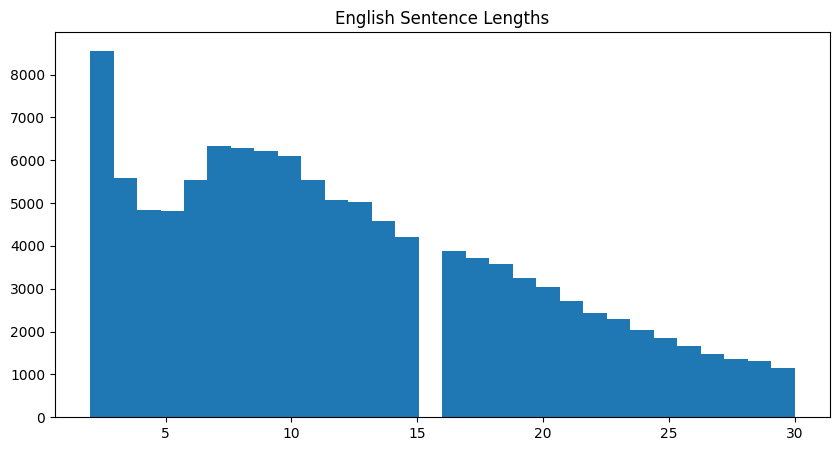

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["en_len"], bins=30)
plt.title("English Sentence Lengths")
plt.show()

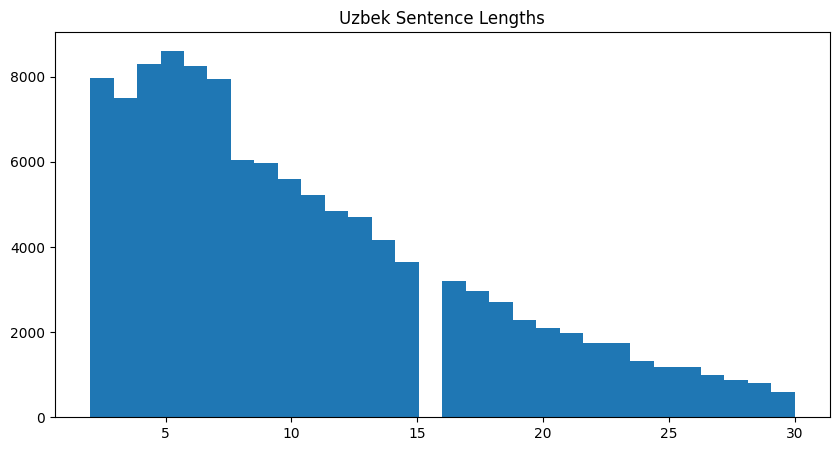

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(df["uz_len"], bins=30)
plt.title("Uzbek Sentence Lengths")
plt.show()

In [ ]:
train_df, valid_df = train_test_split(
    df,
    test_size=0.1,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)

valid_df = valid_df.reset_index(drop=True)

print("Train Size:", len(train_df))
print("Valid Size:", len(valid_df))

Train Size: 103032
Valid Size: 11448


In [ ]:
train_df = train_df[["en", "uz"]]
valid_df = valid_df[["en", "uz"]]

In [ ]:
class Lang:
    def __init__(self, name):
        self.name = name
        self.word2index = {
            "<PAD>": PAD_TOKEN,
            "<SOS>": SOS_TOKEN,
            "<EOS>": EOS_TOKEN,
            "<UNK>": UNK_TOKEN
        }
        self.word2count = {}

        self.index2word = {
            PAD_TOKEN: "<PAD>",
            SOS_TOKEN: "<SOS>",
            EOS_TOKEN: "<EOS>",
            UNK_TOKEN: "<UNK>"
        }

        self.n_words = 4

    def add_sentence(self, sentence):
        for word in sentence.split():
            self.add_word(word)

    def add_word(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.n_words
            self.word2count[word] = 1
            self.index2word[self.n_words] = word
            self.n_words += 1
        else:
            self.word2count[word] += 1

    def trim(self, min_count):
        keep_words = []

        for word, count in self.word2count.items():
            if count >= min_count:
                keep_words.append(word)

        print(f"Keeping {len(keep_words)} / {len(self.word2index)} words")

        # reset dictionaries
        self.word2index = {
            "<PAD>": PAD_TOKEN,
            "<SOS>": SOS_TOKEN,
            "<EOS>": EOS_TOKEN,
            "<UNK>": UNK_TOKEN
        }

        self.index2word = {
            PAD_TOKEN: "<PAD>",
            SOS_TOKEN: "<SOS>",
            EOS_TOKEN: "<EOS>",
            UNK_TOKEN: "<UNK>"
        }

        self.word2count = {}

        self.n_words = 4

        for word in keep_words:
            self.add_word(word)

In [ ]:
input_lang = Lang("english")
output_lang = Lang("uzbek")

In [ ]:
for sentence in tqdm(train_df["en"]):
    input_lang.add_sentence(sentence)

for sentence in tqdm(train_df["uz"]):
    output_lang.add_sentence(sentence)

  0%|          | 0/103032 [00:00<?, ?it/s]

  0%|          | 0/103032 [00:00<?, ?it/s]

In [ ]:
print("English vocab size:", input_lang.n_words)
print("Uzbek vocab size:", output_lang.n_words)

English vocab size: 50735
Uzbek vocab size: 38696


In [ ]:
MIN_WORD_COUNT = 2

input_lang.trim(MIN_WORD_COUNT)

output_lang.trim(MIN_WORD_COUNT)

Keeping 25619 / 50735 words
Keeping 30424 / 38696 words


In [ ]:
def indexes_from_sentence(lang, sentence):
    return [lang.word2index.get(word, UNK_TOKEN) for word in sentence.split()]


def tensor_from_sentence(lang, sentence):
    indexes = indexes_from_sentence(lang, sentence)

    indexes.append(EOS_TOKEN)

    return torch.tensor(indexes, dtype=torch.long)

In [ ]:
sample = train_df["en"][45000]

print(sample)
print(train_df['uz'][45000])

tensor = tensor_from_sentence(input_lang, sample)

print(tensor)

behold! how we expound unto them the evidences!
sodiq, pok bir bandadir. bu kishini ham "ona xudo" deb e'tiqod qilib bo'lmaydi.
tensor([2028,  382,   61, 8557,   46,  199,   72,    3,    2])


In [ ]:
class TranslationDataset(Dataset):
    def __init__(self, dataframe, input_lang, output_lang):
        self.dataframe = dataframe
        self.input_lang = input_lang
        self.output_lang = output_lang

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        en_sentence = self.dataframe.iloc[idx]["en"]
        uz_sentence = self.dataframe.iloc[idx]["uz"]

        # convert to tensors
        src_tensor = tensor_from_sentence(self.input_lang, en_sentence)

        tgt_tensor = tensor_from_sentence(self.output_lang, uz_sentence)

        return src_tensor, tgt_tensor

In [ ]:
def collate_fn(batch):
    src_batch = []
    tgt_batch = []

    for src_sample, tgt_sample in batch:

        src_batch.append(src_sample)
        tgt_batch.append(tgt_sample)

    # pad sequences

    src_batch = pad_sequence(
        src_batch,
        padding_value=PAD_TOKEN,
        batch_first=True
    )

    tgt_batch = pad_sequence(
        tgt_batch,
        padding_value=PAD_TOKEN,
        batch_first=True
    )

    return src_batch, tgt_batch

In [ ]:
train_dataset = TranslationDataset(
    train_df,
    input_lang,
    output_lang
)

valid_dataset = TranslationDataset(
    valid_df,
    input_lang,
    output_lang
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

In [ ]:
src_batch, tgt_batch = next(iter(train_loader))

print(src_batch.shape)
print(tgt_batch.shape)

torch.Size([128, 31])
torch.Size([128, 30])


In [ ]:
# (batch_size, sequence_length)

In [ ]:
class Encoder(nn.Module):
    def __init__(
        self, input_dim, embed_size, hidden_size, num_layers, dropout):
        super().__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        # embedding layer
        self.embedding = nn.Embedding(input_dim, embed_size, padding_idx=PAD_TOKEN)

        # dropout
        self.dropout = nn.Dropout(dropout)

        # bidirectional GRU
        self.gru = nn.GRU(
            embed_size,
            hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0,
            bidirectional=True,
            batch_first=True
        )

        # reduce bidirectional hidden
        self.fc_hidden = nn.Linear(
            hidden_size * 2,
            hidden_size
        )

    def forward(self, x):

        # x shape: (batch_size, seq_length)

        embedded = self.embedding(x)
        embedded = self.dropout(embedded)
        outputs, hidden = self.gru(embedded)
        # outputs: (batch_size, seq_len, hidden*2)

        # get forward & backward hidden states
        forward_hidden = hidden[-2]
        backward_hidden = hidden[-1]

        # concatenate

        hidden = torch.cat(
            (forward_hidden, backward_hidden),
            dim=1
        )

        # reduce dimension
        hidden = self.fc_hidden(hidden)

        # final hidden: (batch_size, hidden_size)

        hidden = torch.tanh(hidden)

        return outputs, hidden

In [ ]:
encoder = Encoder(
    input_dim=input_lang.n_words,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT
).to(device)

In [ ]:
src_batch, tgt_batch = next(iter(train_loader))
src_batch = src_batch.to(device)
outputs, hidden = encoder(src_batch)

print(outputs.shape)
print(hidden.shape)

torch.Size([128, 30, 512])
torch.Size([128, 256])


In [ ]:
# (batch_size, seq_len, hidden_size*2)
# (batch_size, hidden_size)

In [ ]:
class Attention(nn.Module):

    def __init__(self, hidden_size):
        super().__init__()

        self.attn = nn.Linear(hidden_size * 3, hidden_size)
        self.v = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, hidden, encoder_outputs):
        # hidden: (batch_size, hidden_size)
        # encoder_outputs: (batch_size, seq_len, hidden_size*2)

        batch_size = encoder_outputs.shape[0]

        seq_len = encoder_outputs.shape[1]

        # repeat hidden for every timestep
        hidden = hidden.unsqueeze(1).repeat(1, seq_len, 1)

        # concat hidden + encoder outputs
        energy = torch.cat(
            (hidden, encoder_outputs),
            dim=2
        )

        energy = torch.tanh(
            self.attn(energy)
        )

        attention = self.v(energy).squeeze(2)

        # attention scores
        return torch.softmax(attention, dim=1)

In [ ]:
class Decoder(nn.Module):
    def __init__(
        self,
        output_dim,
        embed_size,
        hidden_size,
        num_layers,
        dropout,
        attention
    ):
        super().__init__()

        self.output_dim = output_dim
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.attention = attention

        # embedding
        self.embedding = nn.Embedding(
            output_dim,
            embed_size,
            padding_idx=PAD_TOKEN
        )

        self.dropout = nn.Dropout(dropout)

        # GRU input:
        # embedding + context vector

        self.gru = nn.GRU(
            embed_size + hidden_size * 2,
            hidden_size,
            num_layers=num_layers,
            batch_first=True
        )

        # final prediction layer

        self.fc_out = nn.Linear(
            hidden_size * 3 + embed_size,
            output_dim
        )
    def forward(self, input_token, hidden, encoder_outputs):

        # input_token:
        # (batch_size)

        input_token = input_token.unsqueeze(1)

        # embedding

        embedded = self.embedding(input_token)

        embedded = self.dropout(embedded)

        # attention weights

        attention = self.attention(
            hidden,
            encoder_outputs
        )

        attention = attention.unsqueeze(1)

        # context vector

        context = torch.bmm(
            attention,
            encoder_outputs
        )

        # GRU input

        rnn_input = torch.cat(
            (embedded, context),
            dim=2
        )

        # hidden for GRU

        hidden_gru = hidden.unsqueeze(0)

        output, hidden_new = self.gru(
            rnn_input,
            hidden_gru
        )

        # remove dimensions

        output = output.squeeze(1)

        context = context.squeeze(1)

        embedded = embedded.squeeze(1)

        # prediction

        prediction = self.fc_out(
            torch.cat(
                (
                    output,
                    context,
                    embedded
                ),
                dim=1
            )
        )

        hidden_new = hidden_new.squeeze(0)

        return prediction, hidden_new

In [ ]:
attention = Attention(HIDDEN_SIZE)

In [ ]:
decoder = Decoder(
    output_dim=output_lang.n_words,
    embed_size=EMBED_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    attention=attention
).to(device)

In [ ]:
src_batch, tgt_batch = next(iter(train_loader))

src_batch = src_batch.to(device)

encoder_outputs, hidden = encoder(src_batch)

input_token = tgt_batch[:, 0].to(device)

prediction, hidden = decoder(input_token,hidden,encoder_outputs)

print(prediction.shape)

print(hidden.shape)

torch.Size([128, 30428])
torch.Size([128, 256])


In [ ]:
class Seq2Seq(nn.Module):

    def __init__(
        self,
        encoder,
        decoder,
        device
    ):
        super().__init__()

        self.encoder = encoder
        self.decoder = decoder
        self.device = device

    def forward(
        self,
        src,
        tgt,
        teacher_forcing_ratio=0.5
    ):

        # src:
        # (batch_size, src_len)

        # tgt:
        # (batch_size, tgt_len)

        batch_size = tgt.shape[0]

        tgt_len = tgt.shape[1]

        tgt_vocab_size = self.decoder.output_dim

        # store decoder outputs

        outputs = torch.zeros(
            batch_size,
            tgt_len,
            tgt_vocab_size
        ).to(self.device)

        # encoder outputs

        encoder_outputs, hidden = self.encoder(src)

        # first decoder input = SOS token

        input_token = tgt[:, 0]

        # decode step-by-step

        for t in range(1, tgt_len):

            # decoder prediction

            output, hidden = self.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

            outputs[:, t] = output

            # best predicted token

            best_guess = output.argmax(1)

            # teacher forcing

            teacher_force = random.random() < teacher_forcing_ratio

            input_token = (
                tgt[:, t]
                if teacher_force
                else best_guess
            )

        return outputs

In [ ]:
model = Seq2Seq(encoder, decoder, device).to(device)

In [ ]:
src_batch, tgt_batch = next(iter(train_loader))

src_batch = src_batch.to(device)
tgt_batch = tgt_batch.to(device)

outputs = model(src_batch, tgt_batch)

print(outputs.shape)

torch.Size([128, 30, 30428])


In [ ]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_TOKEN)

In [ ]:
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [ ]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1)

In [ ]:
def count_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

print(f"Trainable Parameters: {count_parameters(model):,}")

Trainable Parameters: 47,443,676


In [ ]:
src_batch, tgt_batch = next(iter(train_loader))

src_batch = src_batch.to(device)
tgt_batch = tgt_batch.to(device)

outputs = model(src_batch, tgt_batch)

In [ ]:
# remove first token (<SOS>)

outputs = outputs[:, 1:, :]

tgt_batch = tgt_batch[:, 1:]

In [ ]:
outputs = outputs.reshape(
    -1,
    outputs.shape[-1]
)

tgt_batch = tgt_batch.reshape(-1)

In [ ]:
loss = criterion(
    outputs,
    tgt_batch
)

print(loss.item())

10.39637565612793


In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, clip):
    model.train()
    epoch_loss = 0

    progress_bar = tqdm(loader)

    for src_batch, tgt_batch in progress_bar:

        src_batch = src_batch.to(device)

        tgt_batch = tgt_batch.to(device)

        # zero gradients

        optimizer.zero_grad()

        # forward pass

        outputs = model(
            src_batch,
            tgt_batch,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO
        )

        # remove SOS token

        outputs = outputs[:, 1:, :]

        tgt_batch = tgt_batch[:, 1:]

        # reshape

        outputs = outputs.reshape(
            -1,
            outputs.shape[-1]
        )

        tgt_batch = tgt_batch.reshape(-1)

        # calculate loss

        loss = criterion(
            outputs,
            tgt_batch
        )

        # backward pass

        loss.backward()

        # gradient clipping

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            clip
        )

        # optimizer step

        optimizer.step()

        epoch_loss += loss.item()

        progress_bar.set_description(
            f"Train Loss: {loss.item():.4f}"
        )

    return epoch_loss / len(loader)

In [ ]:
def evaluate(
    model,
    loader,
    criterion
):

    model.eval()

    epoch_loss = 0

    with torch.no_grad():

        for src_batch, tgt_batch in loader:

            src_batch = src_batch.to(device)

            tgt_batch = tgt_batch.to(device)

            outputs = model(
                src_batch,
                tgt_batch,
                teacher_forcing_ratio=0
            )

            outputs = outputs[:, 1:, :]

            tgt_batch = tgt_batch[:, 1:]

            outputs = outputs.reshape(
                -1,
                outputs.shape[-1]
            )

            tgt_batch = tgt_batch.reshape(-1)

            loss = criterion(
                outputs,
                tgt_batch
            )

            epoch_loss += loss.item()

    return epoch_loss / len(loader)

In [ ]:
N_EPOCHS = NUM_EPOCHS

CLIP = 1

best_valid_loss = float("inf")

train_losses = []

valid_losses = []

In [ ]:
for epoch in range(N_EPOCHS):

    print(f"\nEpoch [{epoch+1}/{N_EPOCHS}]")

    # training

    train_loss = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        CLIP
    )

    # validation

    valid_loss = evaluate(
        model,
        valid_loader,
        criterion
    )

    # scheduler step

    scheduler.step(valid_loss)

    # save losses

    train_losses.append(train_loss)

    valid_losses.append(valid_loss)

    # save best model

    if valid_loss < best_valid_loss:

        best_valid_loss = valid_loss

        torch.save(
            model.state_dict(),
            "best_seq2seq_model.pth"
        )

        print("Best model saved.")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Valid Loss: {valid_loss:.4f}")


Epoch [1/5]


  0%|          | 0/805 [00:00<?, ?it/s]

Best model saved.
Train Loss: 5.8062
Valid Loss: 4.9785

Epoch [2/5]


  0%|          | 0/805 [00:00<?, ?it/s]

Best model saved.
Train Loss: 3.0777
Valid Loss: 4.1454

Epoch [3/5]


...

Best model saved.
Train Loss: 2.2064
Valid Loss: 3.6577

Epoch [4/5]


  0%|          | 0/805 [00:00<?, ?it/s]

Best model saved.
Train Loss: 1.7259
Valid Loss: 3.3722

Epoch [5/5]


  0%|          | 0/805 [00:00<?, ?it/s]

Best model saved.
Train Loss: 1.4019
Valid Loss: 3.1506


In [ ]:
# BATCH_SIZE = 128

# HIDDEN_SIZE = 256

# NUM_EPOCHS = 5

In [ ]:
import os

SAVE_DIR = "/content/saved_model"

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)

print("Save directory created.")

Save directory created.


In [ ]:
checkpoint = {
    # model weights
    "model_state_dict": model.state_dict(),

    # vocabularies
    "input_lang_word2index": input_lang.word2index,
    "input_lang_index2word": input_lang.index2word,
    "output_lang_word2index": output_lang.word2index,
    "output_lang_index2word": output_lang.index2word,

    # vocabulary sizes
    "input_vocab_size": input_lang.n_words,
    "output_vocab_size": output_lang.n_words,

    # hyperparameters
    "embed_size": EMBED_SIZE,
    "hidden_size": HIDDEN_SIZE,
    "num_layers": NUM_LAYERS,
    "dropout": DROPOUT,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

torch.save(
    checkpoint,
    os.path.join(SAVE_DIR, "full_seq2seq_checkpoint.pth")
)

print("FULL CHECKPOINT SAVED")

FULL CHECKPOINT SAVED


In [ ]:
torch.save(
    {
        "train_losses": train_losses,
        "valid_losses": valid_losses
    },
    os.path.join(SAVE_DIR, "losses.pth")
)

print("LOSSES SAVED")

LOSSES SAVED


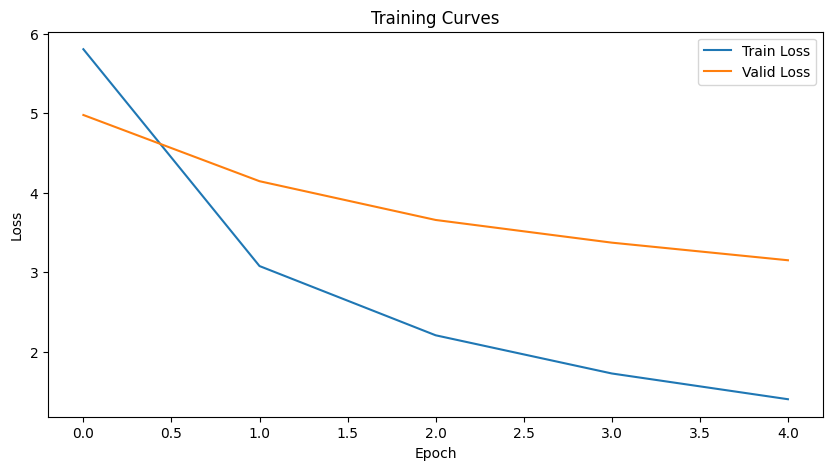

TRAINING CURVE SAVED


In [ ]:
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Train Loss")
plt.plot(valid_losses, label="Valid Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Curves")
plt.savefig(os.path.join(SAVE_DIR, "training_curve.png"))
plt.show()
print("TRAINING CURVE SAVED")

In [ ]:
def translate_sentence(model, sentence, input_lang, output_lang, max_length=MAX_LENGTH):
    model.eval()
    sentence = normalize_string(sentence)
    tokens = sentence.split()

    indexes = [input_lang.word2index.get(token, UNK_TOKEN) for token in tokens]
    indexes.append(EOS_TOKEN)

    src_tensor = torch.tensor(indexes, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        encoder_outputs, hidden = model.encoder(src_tensor)

    input_token = torch.tensor([SOS_TOKEN]).to(device)

    translated_tokens = []

    for _ in range(max_length):
        with torch.no_grad():
            output, hidden = model.decoder(
                input_token,
                hidden,
                encoder_outputs
            )

        best_guess = output.argmax(1).item()

        if best_guess == EOS_TOKEN:
            break

        translated_tokens.append(
            output_lang.index2word.get(
                best_guess,
                "<UNK>"
            )
        )

        input_token = torch.tensor(
            [best_guess]
        ).to(device)

    return " ".join(translated_tokens)

In [ ]:
examples = [
    "These our people have taken to them other gods, apart from Him.",
    "Indeed, Allah is Forgiving and Merciful.",
    "that it is He who causes to laugh and causes to weep.",
    "this is my first translation model",
    "God repelled the unbelievers in their rage."
]

for sentence in examples:
    translation = translate_sentence(
        model,
        sentence,
        input_lang,
        output_lang
    )

    print(f"\nEN: {sentence}")
    print(f"UZ: {translation}")


EN: These our people have taken to them other gods, apart from Him.
UZ: bizning ravshan hujjat bir suvdan yoki undan o'zga hech narsa ila allohdan o'zga hech narsa yo'q.

EN: Indeed, Allah is Forgiving and Merciful.
UZ: alloh mag'firat qiluvchi va o'ta rahmli va mag'firat qilishing durust emas.)

EN: that it is He who causes to laugh and causes to weep.
UZ: qalblarida kuldirgan ham o'zi, yig'latgan ham o'zi.

EN: this is my first translation model
UZ: mening yo'l-allohning yo'li.

EN: God repelled the unbelievers in their rage.
UZ: alloh ularning dillarida yo'q va tug'yonlarida dovdirashlariga


In [ ]:
import shutil

shutil.make_archive(

    "/content/en_uz_translation_model",

    'zip',

    SAVE_DIR
)

print("ZIP FILE CREATED")

ZIP FILE CREATED


In [ ]:
from google.colab import files

files.download(
    "/content/en_uz_translation_model.zip"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
sentence = "So bring our fathers, if you are truthful."

translation = translate_sentence(
        model,
        sentence,
        input_lang,
        output_lang
    )

print(translation)

agar rostgo'y bo'lsangiz, ota-bobolarimizni keltiringlar". yoki azobini keltir", deyishdan boshqa narsa bo'lmadi.
